# APWEB-WAIM 2026 Benchmark Design Materials Generator (Drive-Safe)

This Colab notebook creates paper-ready material for **Section 3: Benchmark Design** of the paper:

**A Benchmark of Small Language Models for Local Text-to-SQL over SQLite**

It does **not** run model inference. It reuses the same Spider data layout and, when available, the same result files produced by the original benchmark notebook. It generates:

- representative Spider example tables;
- compact prompt and repair-prompt listings;
- schema-context examples for Conditions A--D;
- prompt/context-length summaries;
- verification and repair flow diagrams;
- optional example model-output tables from saved benchmark results;
- copy-paste LaTeX snippets for Section 3.


**Update:** This version auto-detects the Spider dataset root and includes a diagnostic search cell to fix missing-path errors.


In [1]:
# Cell 1: Imports and lightweight dependencies.
# This notebook intentionally avoids model loading. It only needs pandas, sqlglot, matplotlib, and pyarrow.

import sys
import subprocess
import importlib.util

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

ensure_package("sqlglot")
ensure_package("pyarrow")
ensure_package("matplotlib")

import os
import re
import json
import math
import sqlite3
import textwrap
from pathlib import Path
from typing import Dict, List, Any, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlglot
from sqlglot import exp

pd.set_option("display.max_colwidth", 160)


In [2]:
# Cell 2: Robust paths, Google Drive mounting, and Spider-root discovery.
#
# Why this cell exists:
# Colab can fail with "Mountpoint must not already contain files" when /content/drive
# already contains files. This cell does NOT delete anything. It tries /content/drive
# only if it is empty/already mounted; otherwise it mounts Drive at a different empty
# folder such as /content/gdrive.
#
# Required Spider layout:
#   dev.json
#   tables.json
#   database/

from pathlib import Path
import os
import shutil
import zipfile

USE_GOOGLE_DRIVE = True        # Set False if you want to work only with uploaded/local files.
AUTO_MOUNT_DRIVE = True        # Set False if Drive mounting is broken and you want local upload only.

# Manual override examples:
# MANUAL_SPIDER_ROOT = Path("/content/gdrive/MyDrive/data/spider")
# MANUAL_SPIDER_ROOT = Path("/content/spider")
MANUAL_SPIDER_ROOT = None

# Optional: if Drive mount is broken, upload spider.zip to Colab's /content and set:
# MANUAL_SPIDER_ZIP = Path("/content/spider.zip")
MANUAL_SPIDER_ZIP = None

def is_probably_drive_mounted(mountpoint: Path) -> bool:
    return (mountpoint / "MyDrive").exists()

def directory_is_empty_or_missing(path: Path) -> bool:
    return (not path.exists()) or (path.is_dir() and not any(path.iterdir()))

def safe_mount_google_drive(preferred_mounts=None):
    """Mount Google Drive without deleting existing /content/drive files."""
    if preferred_mounts is None:
        preferred_mounts = [Path("/content/drive"), Path("/content/gdrive"), Path("/content/drive_mount")]

    try:
        from google.colab import drive  # type: ignore
    except Exception as e:
        print("Not running in Colab or google.colab is unavailable:", repr(e))
        return None

    # If any candidate is already mounted, reuse it.
    for mp in preferred_mounts:
        if is_probably_drive_mounted(mp):
            print(f"Google Drive already appears mounted at: {mp}")
            return mp

    # Otherwise mount only into an empty/nonexistent directory.
    for mp in preferred_mounts:
        try:
            if not directory_is_empty_or_missing(mp):
                print(f"Skipping non-empty mountpoint: {mp}")
                print(f"  Contents: {[p.name for p in list(mp.iterdir())[:10]]}")
                continue
            mp.mkdir(parents=True, exist_ok=True)
            print(f"Trying to mount Google Drive at empty mountpoint: {mp}")
            drive.mount(str(mp), force_remount=False)
            if is_probably_drive_mounted(mp):
                print(f"Mounted Google Drive at: {mp}")
                return mp
        except Exception as e:
            print(f"Could not mount at {mp}: {repr(e)}")

    print("Google Drive was not mounted. The notebook will use local /content paths.")
    return None

DRIVE_MOUNT = None
MYDRIVE = None

if USE_GOOGLE_DRIVE and AUTO_MOUNT_DRIVE:
    DRIVE_MOUNT = safe_mount_google_drive()

if DRIVE_MOUNT is not None:
    MYDRIVE = DRIVE_MOUNT / "MyDrive"
    ROOT = MYDRIVE / "nl2sql_sqlite"
else:
    ROOT = Path("/content/nl2sql_sqlite")

RESULTS_DIR = ROOT / "results"
MATERIALS_DIR = ROOT / "benchmark_design_materials"
MATERIALS_DIR.mkdir(parents=True, exist_ok=True)

def has_spider_layout(path: Path) -> bool:
    return (
        path is not None
        and Path(path).exists()
        and (Path(path) / "dev.json").exists()
        and (Path(path) / "tables.json").exists()
        and (Path(path) / "database").exists()
    )

def maybe_extract_spider_zip(zip_path: Path, out_dir: Path = Path("/content/spider_from_zip")):
    """Extract a local Spider zip and return the folder that contains dev.json/tables.json/database."""
    if zip_path is None or not Path(zip_path).exists():
        return None
    out_dir.mkdir(parents=True, exist_ok=True)
    print("Extracting:", zip_path, "->", out_dir)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

    # Search within extracted tree.
    for dirpath, dirnames, filenames in os.walk(out_dir):
        p = Path(dirpath)
        if "dev.json" in filenames and "tables.json" in filenames and (p / "database").exists():
            return p
    return out_dir

def find_spider_roots(search_roots=None, max_hits: int = 20):
    """Return folders that look like Spider roots. Kept conservative so it is safe in Google Drive."""
    if search_roots is None:
        search_roots = []
        if MYDRIVE is not None:
            search_roots.append(MYDRIVE)
        search_roots.extend([Path("/content"), Path("/content/data")])

    hits = []
    seen = set()
    for base in search_roots:
        if not base.exists():
            continue
        for dirpath, dirnames, filenames in os.walk(base):
            path = Path(dirpath)

            # Avoid large/non-useful folders.
            parts = set(path.parts)
            if ".git" in parts or "__pycache__" in parts or "sample_data" in parts:
                continue

            if "dev.json" in filenames and "tables.json" in filenames and (path / "database").exists():
                resolved = str(path.resolve())
                if resolved not in seen:
                    seen.add(resolved)
                    hits.append(path)
                    if len(hits) >= max_hits:
                        return hits
    return hits

# If a zip was provided manually, extract it first.
EXTRACTED_SPIDER_ROOT = maybe_extract_spider_zip(MANUAL_SPIDER_ZIP) if MANUAL_SPIDER_ZIP is not None else None

CANDIDATE_SPIDER_ROOTS = []
if EXTRACTED_SPIDER_ROOT is not None:
    CANDIDATE_SPIDER_ROOTS.append(Path(EXTRACTED_SPIDER_ROOT))

if MYDRIVE is not None:
    CANDIDATE_SPIDER_ROOTS.extend([
        MYDRIVE / "data/spider",
        MYDRIVE / "spider",
        MYDRIVE / "Spider",
        MYDRIVE / "datasets/spider",
        MYDRIVE / "Datasets/spider",
        MYDRIVE / "nl2sql_sqlite/spider",
        MYDRIVE / "nl2sql_sqlite/data/spider",
    ])

CANDIDATE_SPIDER_ROOTS.extend([
    Path("/content/spider"),
    Path("/content/Spider"),
    Path("/content/data/spider"),
    Path("/content/spider_from_zip"),
])

# Choose SPIDER_ROOT.
if MANUAL_SPIDER_ROOT is not None:
    SPIDER_ROOT = Path(MANUAL_SPIDER_ROOT)
elif any(has_spider_layout(p) for p in CANDIDATE_SPIDER_ROOTS):
    SPIDER_ROOT = next(p for p in CANDIDATE_SPIDER_ROOTS if has_spider_layout(p))
else:
    discovered_spider_roots = find_spider_roots()
    SPIDER_ROOT = discovered_spider_roots[0] if discovered_spider_roots else CANDIDATE_SPIDER_ROOTS[0]

print("DRIVE_MOUNT:", DRIVE_MOUNT)
print("MYDRIVE:", MYDRIVE)
print("ROOT:", ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("SPIDER_ROOT:", SPIDER_ROOT)
print("MATERIALS_DIR:", MATERIALS_DIR)

print("\nSpider layout check:")
for p in [SPIDER_ROOT / "dev.json", SPIDER_ROOT / "tables.json", SPIDER_ROOT / "database"]:
    print(" ", p, "exists=", p.exists())

if not has_spider_layout(SPIDER_ROOT):
    print("\nNo valid Spider root was found automatically.")
    print("A valid Spider folder must contain dev.json, tables.json, and database/.")
    print("\nFast fixes:")
    print("1) If Drive mounted at /content/gdrive, put Spider at /content/gdrive/MyDrive/data/spider")
    print("2) Upload spider.zip to Colab /content, set MANUAL_SPIDER_ZIP = Path('/content/spider.zip'), and rerun this cell")
    print("3) Set MANUAL_SPIDER_ROOT to the exact folder containing dev.json, tables.json, and database/")
    print("4) If you do not need Drive, set USE_GOOGLE_DRIVE = False and use /content paths")

print("\nExpected benchmark result files, if available:")
for p in [
    RESULTS_DIR / "all_model_outputs.parquet",
    RESULTS_DIR / "all_models_main_metrics.csv",
    RESULTS_DIR / "all_models_error_breakdown.csv",
]:
    print(" ", p, "exists=", p.exists())


Trying to mount Google Drive at empty mountpoint: /content/drive
Could not mount at /content/drive: ValueError('mount failed')
Trying to mount Google Drive at empty mountpoint: /content/gdrive
Mounted at /content/gdrive
Mounted Google Drive at: /content/gdrive
DRIVE_MOUNT: /content/gdrive
MYDRIVE: /content/gdrive/MyDrive
ROOT: /content/gdrive/MyDrive/nl2sql_sqlite
RESULTS_DIR: /content/gdrive/MyDrive/nl2sql_sqlite/results
SPIDER_ROOT: /content/gdrive/MyDrive/data/spider
MATERIALS_DIR: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials

Spider layout check:
  /content/gdrive/MyDrive/data/spider/dev.json exists= True
  /content/gdrive/MyDrive/data/spider/tables.json exists= True
  /content/gdrive/MyDrive/data/spider/database exists= True

Expected benchmark result files, if available:
  /content/gdrive/MyDrive/nl2sql_sqlite/results/all_model_outputs.parquet exists= True
  /content/gdrive/MyDrive/nl2sql_sqlite/results/all_models_main_metrics.csv exists= True
  /content/gdriv

## If Google Drive still fails

This notebook can run without Drive. Upload the Spider release as a zip file to Colab, then set:

```python
USE_GOOGLE_DRIVE = False
MANUAL_SPIDER_ZIP = Path("/content/spider.zip")
```

or unzip it yourself so that `MANUAL_SPIDER_ROOT` points to a folder containing `dev.json`, `tables.json`, and `database/`.

Do not delete `/content/drive` unless you are sure the files inside it are temporary. The safer fix is to mount Drive at `/content/gdrive` or `/content/drive_mount`.


In [3]:
# Cell 3: Load Spider dev examples and schema metadata.

# Diagnostic helper: use this if Cell 2 did not find the dataset.
def diagnose_spider_files(search_root: Path = None, max_rows: int = 50):
    if search_root is None:
        search_root = MYDRIVE if MYDRIVE is not None else Path("/content")
    rows = []
    if not search_root.exists():
        print("Search root does not exist:", search_root)
        return pd.DataFrame()
    for dirpath, dirnames, filenames in os.walk(search_root):
        path = Path(dirpath)
        names = set(filenames)
        if "dev.json" in names or "tables.json" in names or (path / "database").exists():
            rows.append({
                "folder": str(path),
                "has_dev_json": "dev.json" in names,
                "has_tables_json": "tables.json" in names,
                "has_database_dir": (path / "database").exists(),
                "valid_spider_root": "dev.json" in names and "tables.json" in names and (path / "database").exists(),
            })
            if len(rows) >= max_rows:
                break
    out = pd.DataFrame(rows)
    if out.empty:
        print("No dev.json, tables.json, or database/ found under", search_root)
    else:
        display(out)
    return out

def assert_spider_layout(spider_root: Path):
    missing = []
    for rel in ["dev.json", "tables.json", "database"]:
        if not (spider_root / rel).exists():
            missing.append(str(spider_root / rel))
    if missing:
        print("Spider root currently set to:", spider_root)
        print("\nNearby diagnostic search:")
        try:
            diagnose_spider_files(None, max_rows=25)
        except Exception as e:
            print("Diagnostic search failed:", repr(e))
        raise FileNotFoundError(
            "Missing Spider files/folders:\n"
            + "\n".join(missing)
            + "\n\nSet MANUAL_SPIDER_ROOT in Cell 2 to the folder containing dev.json, tables.json, and database/."
            + "\nFor example: MANUAL_SPIDER_ROOT = Path('/content/drive/MyDrive/your_folder/spider')"
        )

def load_spider_dev(spider_root: Path) -> Tuple[pd.DataFrame, List[Dict[str, Any]]]:
    assert_spider_layout(spider_root)

    with open(spider_root / "dev.json", "r", encoding="utf-8") as f:
        dev = json.load(f)
    with open(spider_root / "tables.json", "r", encoding="utf-8") as f:
        tables = json.load(f)

    rows = []
    for idx, ex in enumerate(dev):
        rows.append({
            "example_id": idx,
            "db_id": ex["db_id"],
            "question": ex["question"],
            "gold_sql": ex["query"],
        })

    return pd.DataFrame(rows), tables

def sqlite_path_for_db(db_id: str) -> Path:
    return SPIDER_ROOT / "database" / db_id / f"{db_id}.sqlite"

def sqlite_connect_safe(sqlite_path: Path, timeout: float = 3.0):
    conn = sqlite3.connect(str(sqlite_path), timeout=timeout)
    conn.text_factory = lambda b: b.decode("utf-8", errors="replace") if isinstance(b, (bytes, bytearray)) else b
    return conn

dev_df, spider_tables = load_spider_dev(SPIDER_ROOT)

print("Spider dev examples:", len(dev_df))
print("Spider schemas:", len(spider_tables))
print("Example SQLite path exists:", sqlite_path_for_db(dev_df.iloc[0]["db_id"]).exists())
display(dev_df.head(3))


Spider dev examples: 1034
Spider schemas: 166
Example SQLite path exists: True


,example_id,db_id,question,gold_sql
0,0,concert_singer,How many singers do we have?,SELECT count(*) FROM singer
1,1,concert_singer,What is the total number of singers?,SELECT count(*) FROM singer
2,2,concert_singer,"Show name, country, age for all singers ordered by age from the oldest to the youngest.","SELECT name , country , age FROM singer ORDER BY age DESC"


In [4]:
# Cell 4: Schema-context construction copied from the original benchmark logic.

TOP_K_TABLES = 4
SAMPLE_VALUES_PER_TEXT_COL = 3

def normalize_name(text: str) -> List[str]:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9_ ]+", " ", text)
    return [chunk for chunk in text.replace("_", " ").split() if chunk]

def build_schema_index(tables_json: List[Dict[str, Any]]) -> Dict[str, Dict[str, Any]]:
    schema_by_db = {}

    for db in tables_json:
        db_id = db["db_id"]
        table_names = db["table_names_original"]
        col_entries = db["column_names_original"]
        col_types = db["column_types"]
        pk_idxs = set(db["primary_keys"])
        fk_pairs = db["foreign_keys"]

        tables = []
        for t_idx, t_name in enumerate(table_names):
            tables.append({
                "table_id": t_idx,
                "name": t_name,
                "columns": [],
                "primary_keys": [],
                "foreign_keys_out": [],
                "foreign_keys_in": [],
            })

        for c_idx, (t_idx, c_name) in enumerate(col_entries):
            if t_idx == -1:
                continue
            col_obj = {
                "column_id": c_idx,
                "name": c_name,
                "type": col_types[c_idx],
                "is_primary_key": c_idx in pk_idxs,
            }
            tables[t_idx]["columns"].append(col_obj)
            if c_idx in pk_idxs:
                tables[t_idx]["primary_keys"].append(c_name)

        for src_idx, dst_idx in fk_pairs:
            src_t_idx, src_c_name = col_entries[src_idx]
            dst_t_idx, dst_c_name = col_entries[dst_idx]
            if src_t_idx == -1 or dst_t_idx == -1:
                continue

            edge = {
                "from_table": table_names[src_t_idx],
                "from_column": src_c_name,
                "to_table": table_names[dst_t_idx],
                "to_column": dst_c_name,
            }
            tables[src_t_idx]["foreign_keys_out"].append(edge)
            tables[dst_t_idx]["foreign_keys_in"].append(edge)

        schema_by_db[db_id] = {"db_id": db_id, "tables": tables}

    return schema_by_db

SCHEMA_INDEX = build_schema_index(spider_tables)

def gold_sql_tables_columns(sql_text: str) -> Tuple[set, set]:
    tables = set()
    columns = set()
    try:
        tree = sqlglot.parse_one(sql_text, read="sqlite")
        for node in tree.find_all(exp.Table):
            if node.name:
                tables.add(node.name.lower())
        for node in tree.find_all(exp.Column):
            if node.name:
                columns.add(node.name.lower())
    except Exception:
        pass
    return tables, columns

def table_score(question: str, table_obj: Dict[str, Any]) -> float:
    q_tokens = set(normalize_name(question))
    score = 0.0

    table_tokens = set(normalize_name(table_obj["name"]))
    score += len(q_tokens & table_tokens) * 3.0

    for col in table_obj["columns"]:
        col_tokens = set(normalize_name(col["name"]))
        score += len(q_tokens & col_tokens) * 1.0

    return score

def select_tables_conservative(question: str, schema: Dict[str, Any], top_k: int = TOP_K_TABLES) -> List[Dict[str, Any]]:
    scored = []
    for table in schema["tables"]:
        scored.append((table_score(question, table), table))

    scored.sort(key=lambda x: x[0], reverse=True)
    top = [t for s, t in scored[:top_k] if s > 0]

    if not top:
        return schema["tables"][:]

    selected_names = {t["name"] for t in top}
    all_tables = {t["name"]: t for t in schema["tables"]}

    for t in top[:]:
        for edge in t["foreign_keys_out"] + t["foreign_keys_in"]:
            if edge["from_table"] in all_tables:
                selected_names.add(edge["from_table"])
            if edge["to_table"] in all_tables:
                selected_names.add(edge["to_table"])

    return [all_tables[name] for name in selected_names]

def fetch_sample_values(db_id: str, table_name: str, column_name: str, limit: int = SAMPLE_VALUES_PER_TEXT_COL) -> List[str]:
    samples = []
    sqlite_path = sqlite_path_for_db(db_id)

    try:
        conn = sqlite_connect_safe(sqlite_path)
        q = (
            f'SELECT DISTINCT "{column_name}" '
            f'FROM "{table_name}" '
            f'WHERE "{column_name}" IS NOT NULL '
            f'LIMIT {limit}'
        )
        rows = conn.execute(q).fetchall()
        conn.close()

        for r in rows:
            v = r[0]
            if isinstance(v, bytes):
                v = v.decode("utf-8", errors="replace")
            if isinstance(v, str):
                v = v.replace("\\x00", "")
                if len(v) <= 40:
                    samples.append(v)
    except Exception:
        pass

    return samples

def schema_to_text(db_id: str, schema_tables: List[Dict[str, Any]], augmented: bool = False) -> str:
    lines = []

    for table in sorted(schema_tables, key=lambda x: x["name"].lower()):
        lines.append(f'Table: {table["name"]}')

        for col in table["columns"]:
            if augmented:
                col_line = f'- {col["name"]} {str(col["type"]).upper()}'
                if col.get("is_primary_key", False):
                    col_line += ", primary key"
                if str(col["type"]).lower() in {"text", "varchar"}:
                    vals = fetch_sample_values(db_id, table["name"], col["name"])
                    if vals:
                        vals_str = ", ".join([repr(v) for v in vals[:SAMPLE_VALUES_PER_TEXT_COL]])
                        col_line += f", sample values: {vals_str}"
                lines.append(col_line)
            else:
                lines.append(f'- {col["name"]}')

        lines.append("")

    fk_lines = []
    for table in schema_tables:
        for edge in table["foreign_keys_out"]:
            fk_lines.append(f'{edge["from_table"]}.{edge["from_column"]} -> {edge["to_table"]}.{edge["to_column"]}')

    if fk_lines:
        lines.append("Foreign keys:")
        for x in sorted(set(fk_lines)):
            lines.append(x)

    return "\n".join(lines).strip()

def build_schema_context(db_id: str, question: str, gold_sql: Optional[str], context_mode: str) -> Dict[str, Any]:
    schema = SCHEMA_INDEX[db_id]

    full_tables = schema["tables"]
    full_context = schema_to_text(db_id, full_tables, augmented=False)

    if context_mode == "full":
        selected_tables = full_tables
        schema_context = full_context
        augmented = False
    elif context_mode == "pruned":
        selected_tables = select_tables_conservative(question, schema, TOP_K_TABLES)
        schema_context = schema_to_text(db_id, selected_tables, augmented=False)
        augmented = False
    elif context_mode == "pruned_augmented":
        selected_tables = select_tables_conservative(question, schema, TOP_K_TABLES)
        schema_context = schema_to_text(db_id, selected_tables, augmented=True)
        augmented = True
    else:
        raise ValueError(f"Unknown context_mode: {context_mode}")

    gold_tables, gold_columns = gold_sql_tables_columns(gold_sql or "")
    selected_table_names = {t["name"].lower() for t in selected_tables}
    selected_column_names = {c["name"].lower() for t in selected_tables for c in t["columns"]}

    gold_table_recall = int(gold_tables.issubset(selected_table_names)) if gold_tables else 1
    gold_column_recall = int(gold_columns.issubset(selected_column_names)) if gold_columns else 1

    pruning_failure = int(
        (context_mode != "full")
        and (
            not gold_tables.issubset(selected_table_names)
            or not gold_columns.issubset(selected_column_names)
        )
    )

    return {
        "db_id": db_id,
        "context_mode": context_mode,
        "schema_context": schema_context,
        "schema_context_chars": len(schema_context),
        "full_schema_chars": len(full_context),
        "schema_compression_ratio": len(schema_context) / max(len(full_context), 1),
        "selected_tables": [t["name"] for t in selected_tables],
        "gold_table_recall": gold_table_recall,
        "gold_column_recall": gold_column_recall,
        "pruning_failure": pruning_failure,
        "augmented": augmented,
    }

print("Schema index built for databases:", len(SCHEMA_INDEX))


Schema index built for databases: 166


In [5]:
# Cell 5: Exact prompt templates used by the benchmark.

SYSTEM_PROMPT = (
    "You are a careful SQL assistant. "
    "Generate exactly one SQLite-compatible SELECT query that answers the user question. "
    "Return only the SQL query. Do not explain. Do not include markdown fences."
)

def build_generation_prompt(question: str, schema_context: str) -> str:
    return (
        "You are given a database schema and a user question.\n"
        "Generate one SQLite-compatible SQL query that answers the question.\n"
        "Return only the SQL query. Do not explain.\n\n"
        f"Schema:\n{schema_context}\n\n"
        f"Question:\n{question}\n\n"
        "SQL:\n"
    )

def build_repair_prompt(question: str, schema_context: str, failed_sql: str, error_message: str) -> str:
    return (
        "The SQL query below failed.\n\n"
        f"Schema:\n{schema_context}\n\n"
        f"Question:\n{question}\n\n"
        f"Failed SQL:\n{failed_sql}\n\n"
        f"Error:\n{error_message}\n\n"
        "Return one corrected SQLite-compatible SELECT query.\n"
        "Return only the SQL query.\n"
    )

prompt_template_rows = pd.DataFrame([
    {
        "component": "System instruction",
        "included_in": "All conditions",
        "purpose": "Constrains the model to one SQLite-compatible SELECT query and no explanation.",
        "text": SYSTEM_PROMPT,
    },
    {
        "component": "Generation user prompt",
        "included_in": "All conditions",
        "purpose": "Provides the condition-specific schema context, question, and SQL field.",
        "text": "Schema + Question + SQL:",
    },
    {
        "component": "Repair user prompt",
        "included_in": "Condition D only",
        "purpose": "Provides the same schema and question plus failed SQL and verifier error.",
        "text": "Schema + Question + Failed SQL + Error + corrected SQL instruction",
    },
])

prompt_template_rows.to_csv(MATERIALS_DIR / "prompt_components.csv", index=False)
display(prompt_template_rows)


,component,included_in,purpose,text
0,System instruction,All conditions,Constrains the model to one SQLite-compatible SELECT query and no explanation.,You are a careful SQL assistant. Generate exactly one SQLite-compatible SELECT query that answers the user question. Return only the SQL query. Do not expla...
1,Generation user prompt,All conditions,"Provides the condition-specific schema context, question, and SQL field.",Schema + Question + SQL:
2,Repair user prompt,Condition D only,Provides the same schema and question plus failed SQL and verifier error.,Schema + Question + Failed SQL + Error + corrected SQL instruction


In [6]:
# Cell 6: SQL structure tags for representative example selection.

def sql_structure_tags(sql_text: str) -> List[str]:
    s = " " + re.sub(r"\s+", " ", str(sql_text).lower()).strip() + " "
    tags = []

    try:
        tree = sqlglot.parse_one(sql_text, read="sqlite")
        table_names = {t.name.lower() for t in tree.find_all(exp.Table) if t.name}
        if len(table_names) >= 2:
            tags.append("multi-table/join")
    except Exception:
        pass

    if any(x in s for x in [" count(", " sum(", " avg(", " min(", " max("]):
        tags.append("aggregation")
    if " group by " in s:
        tags.append("group-by")
    if " order by " in s:
        tags.append("order-by")
    if " limit " in s:
        tags.append("limit")
    if s.count("select") >= 2:
        tags.append("nested")
    if not tags:
        tags.append("simple")
    return tags

def choose_representative_examples(df: pd.DataFrame) -> pd.DataFrame:
    candidates = df.copy()
    candidates["structure_tags"] = candidates["gold_sql"].apply(lambda x: ", ".join(sql_structure_tags(x)))
    candidates["question_len"] = candidates["question"].str.len()
    candidates["sql_len"] = candidates["gold_sql"].str.len()

    targets = [
        ("Simple lookup", lambda r: r["structure_tags"] == "simple"),
        ("Aggregation", lambda r: "aggregation" in r["structure_tags"]),
        ("Join or multi-table", lambda r: "multi-table/join" in r["structure_tags"]),
        ("Nested query", lambda r: "nested" in r["structure_tags"]),
        ("Order/limit", lambda r: ("order-by" in r["structure_tags"]) or ("limit" in r["structure_tags"])),
    ]

    selected_rows = []
    used = set()

    for label, pred in targets:
        sub = candidates[candidates.apply(pred, axis=1)].copy()
        sub = sub[~sub["example_id"].isin(used)]
        if sub.empty:
            continue
        sub["readability_score"] = (
            (sub["question_len"] - 80).abs()
            + 0.4 * (sub["sql_len"] - 120).abs()
        )
        row = sub.sort_values(["readability_score", "example_id"]).iloc[0].copy()
        row["example_type"] = label
        selected_rows.append(row)
        used.add(int(row["example_id"]))

    return pd.DataFrame(selected_rows)

example_entries = choose_representative_examples(dev_df)

summary_rows = []
for _, row in example_entries.iterrows():
    contexts = {
        "A": build_schema_context(row["db_id"], row["question"], row["gold_sql"], "full"),
        "B": build_schema_context(row["db_id"], row["question"], row["gold_sql"], "pruned"),
        "C": build_schema_context(row["db_id"], row["question"], row["gold_sql"], "pruned_augmented"),
        "D": build_schema_context(row["db_id"], row["question"], row["gold_sql"], "pruned_augmented"),
    }
    summary_rows.append({
        "example_type": row["example_type"],
        "example_id": int(row["example_id"]),
        "db_id": row["db_id"],
        "question": row["question"],
        "gold_sql": row["gold_sql"],
        "structure_tags": row["structure_tags"],
        "condition_A_schema_chars": contexts["A"]["schema_context_chars"],
        "condition_B_schema_chars": contexts["B"]["schema_context_chars"],
        "condition_C_or_D_schema_chars": contexts["C"]["schema_context_chars"],
        "selected_tables_B": ", ".join(contexts["B"]["selected_tables"]),
        "selected_tables_C_or_D": ", ".join(contexts["C"]["selected_tables"]),
        "pruning_failure_B": contexts["B"]["pruning_failure"],
        "pruning_failure_C_or_D": contexts["C"]["pruning_failure"],
    })

example_entries_table = pd.DataFrame(summary_rows)
example_entries_table.to_csv(MATERIALS_DIR / "benchmark_design_example_entries.csv", index=False)

display(example_entries_table)
print("Saved:", MATERIALS_DIR / "benchmark_design_example_entries.csv")


,example_type,example_id,db_id,question,gold_sql,structure_tags,condition_A_schema_chars,condition_B_schema_chars,condition_C_or_D_schema_chars,selected_tables_B,selected_tables_C_or_D,pruning_failure_B,pruning_failure_C_or_D
0,Simple lookup,303,cre_Doc_Template_Mgt,"What is the document id, template id and description for document named ""Robbin CV""?","SELECT document_id , template_id , Document_Description FROM Documents WHERE document_name = ""Robbin CV""",simple,567,567,1018,"Paragraphs, Documents, Templates, Ref_Template_Types","Paragraphs, Documents, Templates, Ref_Template_Types",1,1
1,Aggregation,159,car_1,How many cars have a larger accelerate than the car with the largest horsepower?,SELECT COUNT(*) FROM CARS_DATA WHERE Accelerate > ( SELECT Accelerate FROM CARS_DATA ORDER BY Horsepower DESC LIMIT 1 );,"aggregation, order-by, limit, nested",527,487,1101,"countries, model_list, car_names, car_makers, cars_data","countries, model_list, car_names, car_makers, cars_data",0,0
2,Join or multi-table,634,tvshow,What are the countries that have cartoons on TV that were written by Todd Casey?,SELECT T1.country FROM TV_Channel AS T1 JOIN cartoon AS T2 ON T1.id = T2.Channel WHERE T2.written_by = 'Todd Casey',multi-table/join,455,455,1639,"Cartoon, TV_Channel, TV_series","Cartoon, TV_Channel, TV_series",0,0
3,Nested query,1028,singer,Show the citizenship shared by singers with birth year before 1945 and after 1955.,SELECT Citizenship FROM singer WHERE Birth_Year < 1945 INTERSECT SELECT Citizenship FROM singer WHERE Birth_Year > 1955,nested,200,200,511,"singer, song","singer, song",0,0
4,Order/limit,43,concert_singer,Find the number of concerts happened in the stadium with the highest capacity.,SELECT count(*) FROM concert AS T1 JOIN stadium AS T2 ON T1.stadium_id = T2.stadium_id ORDER BY T2.Capacity DESC LIMIT 1,"multi-table/join, aggregation, order-by, limit",455,455,1172,"singer_in_concert, singer, stadium, concert","singer_in_concert, singer, stadium, concert",0,0


Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/benchmark_design_example_entries.csv


In [7]:
# Cell 7: Export a compact LaTeX table for representative benchmark examples.

def latex_escape(s: Any) -> str:
    s = str(s)
    repl = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for k, v in repl.items():
        s = s.replace(k, v)
    return s

def shorten(s: Any, n: int = 110) -> str:
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s if len(s) <= n else s[: n - 3] + "..."

compact = example_entries_table.copy()
compact["question_short"] = compact["question"].apply(lambda x: shorten(x, 95))
compact["gold_sql_short"] = compact["gold_sql"].apply(lambda x: shorten(x, 120))
compact["schema_chars"] = compact.apply(
    lambda r: f'{r["condition_A_schema_chars"]}/{r["condition_B_schema_chars"]}/{r["condition_C_or_D_schema_chars"]}',
    axis=1,
)

latex_lines = []
latex_lines.append(r"\begin{table}[!tbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Representative Spider development examples used to illustrate the benchmark design. Schema characters are shown for Conditions A/B/C--D.}")
latex_lines.append(r"\label{tab:benchmark_examples}")
latex_lines.append(r"\scriptsize")
latex_lines.append(r"\begin{tabular}{p{2.0cm}p{1.6cm}p{4.3cm}p{4.0cm}p{1.4cm}}")
latex_lines.append(r"\toprule")
latex_lines.append(r"\textbf{Type} & \textbf{DB} & \textbf{Question} & \textbf{Gold SQL} & \textbf{Chars A/B/C--D} \\")
latex_lines.append(r"\midrule")
for _, r in compact.iterrows():
    latex_lines.append(
        f'{latex_escape(r["example_type"])} & '
        f'{latex_escape(r["db_id"])} & '
        f'{latex_escape(r["question_short"])} & '
        f'{latex_escape(r["gold_sql_short"])} & '
        f'{latex_escape(r["schema_chars"])} \\\\'
    )
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)
(MATERIALS_DIR / "tab_benchmark_examples.tex").write_text(latex_table, encoding="utf-8")

print(latex_table)
print("\nSaved:", MATERIALS_DIR / "tab_benchmark_examples.tex")


\begin{table}[!tbp]
\centering
\caption{Representative Spider development examples used to illustrate the benchmark design. Schema characters are shown for Conditions A/B/C--D.}
\label{tab:benchmark_examples}
\scriptsize
\begin{tabular}{p{2.0cm}p{1.6cm}p{4.3cm}p{4.0cm}p{1.4cm}}
\toprule
\textbf{Type} & \textbf{DB} & \textbf{Question} & \textbf{Gold SQL} & \textbf{Chars A/B/C--D} \\
\midrule
Simple lookup & cre\_Doc\_Template\_Mgt & What is the document id, template id and description for document named "Robbin CV"? & SELECT document\_id , template\_id , Document\_Description FROM Documents WHERE document\_name = "Robbin CV" & 567/567/1018 \\
Aggregation & car\_1 & How many cars have a larger accelerate than the car with the largest horsepower? & SELECT COUNT(*) FROM CARS\_DATA WHERE Accelerate > ( SELECT Accelerate FROM CARS\_DATA ORDER BY Horsepower DESC LIMIT 1 ); & 527/487/1101 \\
Join or multi-table & tvshow & What are the countries that have cartoons on TV that were written by Tod

In [8]:
# Cell 8: Compute schema-context and prompt-size summaries over the full Spider dev set.

condition_map = {
    "A": "full",
    "B": "pruned",
    "C": "pruned_augmented",
    "D": "pruned_augmented",
}

context_rows = []
for _, row in dev_df.iterrows():
    for condition, mode in condition_map.items():
        ctx = build_schema_context(row["db_id"], row["question"], row["gold_sql"], mode)
        generation_prompt = build_generation_prompt(row["question"], ctx["schema_context"])

        context_rows.append({
            "example_id": int(row["example_id"]),
            "db_id": row["db_id"],
            "condition": condition,
            "context_mode": mode,
            "schema_context_chars": ctx["schema_context_chars"],
            "full_schema_chars": ctx["full_schema_chars"],
            "schema_compression_ratio": ctx["schema_compression_ratio"],
            "selected_table_count": len(ctx["selected_tables"]),
            "selected_tables": ", ".join(ctx["selected_tables"]),
            "gold_table_recall": ctx["gold_table_recall"],
            "gold_column_recall": ctx["gold_column_recall"],
            "pruning_failure": ctx["pruning_failure"],
            "prompt_input_chars": len(generation_prompt),
        })

context_metrics = pd.DataFrame(context_rows)
context_metrics.to_csv(MATERIALS_DIR / "schema_context_and_prompt_metrics.csv", index=False)

context_summary = (
    context_metrics
    .groupby("condition")
    .agg(
        examples=("example_id", "count"),
        mean_schema_chars=("schema_context_chars", "mean"),
        median_schema_chars=("schema_context_chars", "median"),
        p95_schema_chars=("schema_context_chars", lambda x: float(np.percentile(x, 95))),
        mean_prompt_chars=("prompt_input_chars", "mean"),
        median_prompt_chars=("prompt_input_chars", "median"),
        mean_compression_ratio=("schema_compression_ratio", "mean"),
        mean_selected_tables=("selected_table_count", "mean"),
        gold_table_recall=("gold_table_recall", "mean"),
        gold_column_recall=("gold_column_recall", "mean"),
        pruning_failure_rate=("pruning_failure", "mean"),
    )
    .reset_index()
)

context_summary.to_csv(MATERIALS_DIR / "schema_context_and_prompt_summary.csv", index=False)

display(context_summary)
print("Saved:", MATERIALS_DIR / "schema_context_and_prompt_metrics.csv")
print("Saved:", MATERIALS_DIR / "schema_context_and_prompt_summary.csv")


,condition,examples,mean_schema_chars,median_schema_chars,p95_schema_chars,mean_prompt_chars,median_prompt_chars,mean_compression_ratio,mean_selected_tables,gold_table_recall,gold_column_recall,pruning_failure_rate
0,A,1034,585.581238,455.0,1864.0,845.532882,725.0,1.000000,4.523211,1.000000,0.794004,0.000000
1,B,1034,494.806576,423.0,1282.0,754.758221,689.5,0.887426,3.605416,0.978723,0.786267,0.220503
2,C,1034,1205.841393,1018.0,3081.0,1465.793037,1310.5,2.190739,3.605416,0.978723,0.786267,0.220503
3,D,1034,1205.841393,1018.0,3081.0,1465.793037,1310.5,2.190739,3.605416,0.978723,0.786267,0.220503


Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/schema_context_and_prompt_metrics.csv
Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/schema_context_and_prompt_summary.csv


/tmp/ipykernel_4118/711406185.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["A full", "B pruned", "C aug.", "D aug.+repair"], showfliers=False)


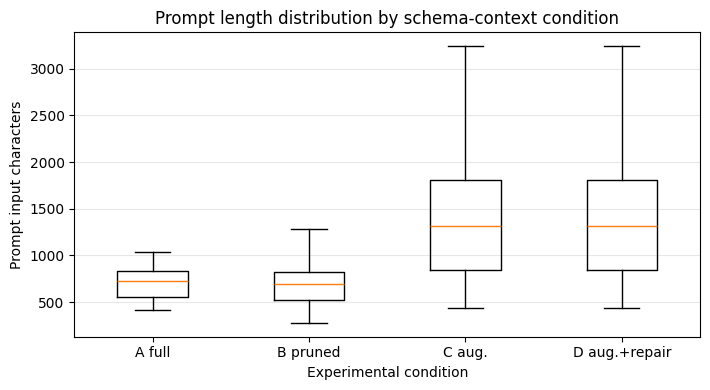

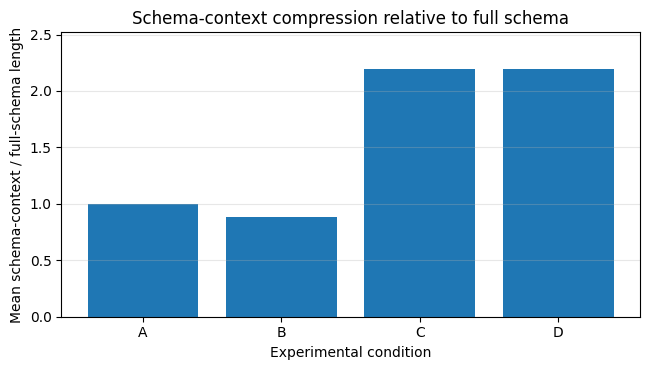

Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_prompt_length_by_condition.png
Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_schema_context_compression.png


In [9]:
# Cell 9: Generate schema-context length figures.

# Figure 1: boxplot of prompt length by condition.
fig, ax = plt.subplots(figsize=(7.2, 4.0))
data = [
    context_metrics[context_metrics["condition"] == c]["prompt_input_chars"].values
    for c in ["A", "B", "C", "D"]
]
ax.boxplot(data, labels=["A full", "B pruned", "C aug.", "D aug.+repair"], showfliers=False)
ax.set_ylabel("Prompt input characters")
ax.set_xlabel("Experimental condition")
ax.set_title("Prompt length distribution by schema-context condition")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig_path = MATERIALS_DIR / "fig_prompt_length_by_condition.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: mean schema compression ratio by condition.
fig, ax = plt.subplots(figsize=(6.6, 3.8))
plot_df = context_summary.copy()
ax.bar(plot_df["condition"], plot_df["mean_compression_ratio"])
ax.set_ylim(0, max(1.05, float(plot_df["mean_compression_ratio"].max()) * 1.15))
ax.set_xlabel("Experimental condition")
ax.set_ylabel("Mean schema-context / full-schema length")
ax.set_title("Schema-context compression relative to full schema")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig_path2 = MATERIALS_DIR / "fig_schema_context_compression.png"
fig.savefig(fig_path2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("Saved:", fig_path2)


In [10]:
# Cell 10: Export the schema-context summary as a compact LaTeX table.

latex_lines = []
latex_lines.append(r"\begin{table}[!tbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Schema-context and prompt-size statistics over the Spider development set. Conditions C and D use the same schema context; D additionally enables one-step repair after verification failure.}")
latex_lines.append(r"\label{tab:context_prompt_stats}")
latex_lines.append(r"\scriptsize")
latex_lines.append(r"\begin{tabular}{crrrrrr}")
latex_lines.append(r"\toprule")
latex_lines.append(r"\textbf{Cond.} & \textbf{Median schema chars} & \textbf{P95 schema chars} & \textbf{Median prompt chars} & \textbf{Mean comp.} & \textbf{Gold table recall} & \textbf{Prune fail.} \\")
latex_lines.append(r"\midrule")
for _, r in context_summary.iterrows():
    latex_lines.append(
        f'{r["condition"]} & '
        f'{r["median_schema_chars"]:.0f} & '
        f'{r["p95_schema_chars"]:.0f} & '
        f'{r["median_prompt_chars"]:.0f} & '
        f'{r["mean_compression_ratio"]:.2f} & '
        f'{100*r["gold_table_recall"]:.1f}\\% & '
        f'{100*r["pruning_failure_rate"]:.1f}\\% \\\\'
    )
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")

latex_context_table = "\n".join(latex_lines)
(MATERIALS_DIR / "tab_context_prompt_stats.tex").write_text(latex_context_table, encoding="utf-8")

print(latex_context_table)
print("\nSaved:", MATERIALS_DIR / "tab_context_prompt_stats.tex")


\begin{table}[!tbp]
\centering
\caption{Schema-context and prompt-size statistics over the Spider development set. Conditions C and D use the same schema context; D additionally enables one-step repair after verification failure.}
\label{tab:context_prompt_stats}
\scriptsize
\begin{tabular}{crrrrrr}
\toprule
\textbf{Cond.} & \textbf{Median schema chars} & \textbf{P95 schema chars} & \textbf{Median prompt chars} & \textbf{Mean comp.} & \textbf{Gold table recall} & \textbf{Prune fail.} \\
\midrule
A & 455 & 1864 & 725 & 1.00 & 100.0\% & 0.0\% \\
B & 423 & 1282 & 690 & 0.89 & 97.9\% & 22.1\% \\
C & 1018 & 3081 & 1310 & 2.19 & 97.9\% & 22.1\% \\
D & 1018 & 3081 & 1310 & 2.19 & 97.9\% & 22.1\% \\
\bottomrule
\end{tabular}
\end{table}

Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/tab_context_prompt_stats.tex


In [11]:
# Cell 11: Create a concrete prompt/schema example for one representative entry.
# This is useful as an appendix listing or a compact figure/table in Section 3.

preferred = example_entries_table[
    example_entries_table["example_type"].isin(["Join or multi-table", "Nested query", "Aggregation"])
].copy()

if preferred.empty:
    ex = example_entries_table.iloc[0]
else:
    ex = preferred.iloc[0]

example_id = int(ex["example_id"])
example_row = dev_df[dev_df["example_id"] == example_id].iloc[0]

contexts = {
    "A_full_schema": build_schema_context(example_row["db_id"], example_row["question"], example_row["gold_sql"], "full"),
    "B_pruned_schema": build_schema_context(example_row["db_id"], example_row["question"], example_row["gold_sql"], "pruned"),
    "C_D_pruned_augmented_schema": build_schema_context(example_row["db_id"], example_row["question"], example_row["gold_sql"], "pruned_augmented"),
}

example_bundle_lines = []
example_bundle_lines.append("# Representative benchmark example")
example_bundle_lines.append("")
example_bundle_lines.append(f"- example_id: {example_id}")
example_bundle_lines.append(f"- db_id: {example_row['db_id']}")
example_bundle_lines.append(f"- question: {example_row['question']}")
example_bundle_lines.append(f"- gold_sql: `{example_row['gold_sql']}`")
example_bundle_lines.append("")

for name, ctx in contexts.items():
    example_bundle_lines.append(f"## {name}")
    example_bundle_lines.append("")
    example_bundle_lines.append(f"- selected_tables: {', '.join(ctx['selected_tables'])}")
    example_bundle_lines.append(f"- schema_context_chars: {ctx['schema_context_chars']}")
    example_bundle_lines.append(f"- schema_compression_ratio: {ctx['schema_compression_ratio']:.3f}")
    example_bundle_lines.append("")
    example_bundle_lines.append("```text")
    example_bundle_lines.append(ctx["schema_context"])
    example_bundle_lines.append("```")
    example_bundle_lines.append("")

condition_d_prompt = build_generation_prompt(
    example_row["question"],
    contexts["C_D_pruned_augmented_schema"]["schema_context"],
)

repair_prompt_demo = build_repair_prompt(
    example_row["question"],
    contexts["C_D_pruned_augmented_schema"]["schema_context"],
    "SELECT * FROM missing_table;",
    "Unknown referenced table(s): ['missing_table']",
)

example_bundle_lines.append("## Condition D generation prompt")
example_bundle_lines.append("")
example_bundle_lines.append("```text")
example_bundle_lines.append("SYSTEM:")
example_bundle_lines.append(SYSTEM_PROMPT)
example_bundle_lines.append("")
example_bundle_lines.append("USER:")
example_bundle_lines.append(condition_d_prompt)
example_bundle_lines.append("```")
example_bundle_lines.append("")

example_bundle_lines.append("## Condition D repair prompt example")
example_bundle_lines.append("")
example_bundle_lines.append("```text")
example_bundle_lines.append(repair_prompt_demo)
example_bundle_lines.append("```")

example_md = "\n".join(example_bundle_lines)
(MATERIALS_DIR / "representative_prompt_and_schema_example.md").write_text(example_md, encoding="utf-8")
(MATERIALS_DIR / "condition_D_prompt_example.txt").write_text(condition_d_prompt, encoding="utf-8")
(MATERIALS_DIR / "condition_D_repair_prompt_example.txt").write_text(repair_prompt_demo, encoding="utf-8")

print(example_md[:4000])
print("\nSaved:")
print(" ", MATERIALS_DIR / "representative_prompt_and_schema_example.md")
print(" ", MATERIALS_DIR / "condition_D_prompt_example.txt")
print(" ", MATERIALS_DIR / "condition_D_repair_prompt_example.txt")


# Representative benchmark example

- example_id: 159
- db_id: car_1
- question: How many cars have a larger accelerate than the car with the largest horsepower?
- gold_sql: `SELECT COUNT(*) FROM CARS_DATA WHERE Accelerate  >  ( SELECT Accelerate FROM CARS_DATA ORDER BY Horsepower DESC LIMIT 1 );`

## A_full_schema

- selected_tables: continents, countries, car_makers, model_list, car_names, cars_data
- schema_context_chars: 527
- schema_compression_ratio: 1.000

```text
Table: car_makers
- Id
- Maker
- FullName
- Country

Table: car_names
- MakeId
- Model
- Make

Table: cars_data
- Id
- MPG
- Cylinders
- Edispl
- Horsepower
- Weight
- Accelerate
- Year

Table: continents
- ContId
- Continent

Table: countries
- CountryId
- CountryName
- Continent

Table: model_list
- ModelId
- Maker
- Model

Foreign keys:
car_makers.Country -> countries.CountryId
car_names.Model -> model_list.Model
cars_data.Id -> car_names.MakeId
countries.Continent -> continents.ContId
model_list.Maker -> car_makers

In [12]:
# Cell 12: Export compact LaTeX prompt listings.

prompt_listing = r'''\begin{figure}[!tbp]
\centering
\scriptsize
\begin{minipage}{0.94\textwidth}
\begin{verbatim}
System:
You are a careful SQL assistant. Generate exactly one SQLite-compatible
SELECT query that answers the user question. Return only the SQL query.
Do not explain. Do not include markdown fences.

User:
You are given a database schema and a user question.
Generate one SQLite-compatible SQL query that answers the question.
Return only the SQL query. Do not explain.

Schema:
<condition-specific schema context>

Question:
<natural-language question>

SQL:
\end{verbatim}
\end{minipage}
\caption{Generation prompt template. The schema block is replaced by the full, pruned, or pruned augmented schema context depending on the experimental condition.}
\label{fig:generation_prompt}
\end{figure}
'''

repair_listing = r'''\begin{figure}[!tbp]
\centering
\scriptsize
\begin{minipage}{0.94\textwidth}
\begin{verbatim}
The SQL query below failed.

Schema:
<same pruned augmented schema context>

Question:
<natural-language question>

Failed SQL:
<failed SQL>

Error:
<verification error>

Return one corrected SQLite-compatible SELECT query.
Return only the SQL query.
\end{verbatim}
\end{minipage}
\caption{One-step repair prompt used only in Condition D after verification failure.}
\label{fig:repair_prompt}
\end{figure}
'''

(MATERIALS_DIR / "fig_generation_prompt_template.tex").write_text(prompt_listing, encoding="utf-8")
(MATERIALS_DIR / "fig_repair_prompt_template.tex").write_text(repair_listing, encoding="utf-8")

print(prompt_listing)
print("\nSaved:")
print(" ", MATERIALS_DIR / "fig_generation_prompt_template.tex")
print(" ", MATERIALS_DIR / "fig_repair_prompt_template.tex")


\begin{figure}[!tbp]
\centering
\scriptsize
\begin{minipage}{0.94\textwidth}
\begin{verbatim}
System:
You are a careful SQL assistant. Generate exactly one SQLite-compatible
SELECT query that answers the user question. Return only the SQL query.
Do not explain. Do not include markdown fences.

User:
You are given a database schema and a user question.
Generate one SQLite-compatible SQL query that answers the question.
Return only the SQL query. Do not explain.

Schema:
<condition-specific schema context>

Question:
<natural-language question>

SQL:
\end{verbatim}
\end{minipage}
\caption{Generation prompt template. The schema block is replaced by the full, pruned, or pruned augmented schema context depending on the experimental condition.}
\label{fig:generation_prompt}
\end{figure}


Saved:
  /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_generation_prompt_template.tex
  /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_repair_prompt_template.tex

In [13]:
# Cell 13: Verification and repair flow table.

verification_rows = pd.DataFrame([
    {
        "stage": "Output extraction",
        "check": "Remove reasoning/markdown wrappers and extract first SELECT statement.",
        "failure_label": "empty_raw, no_select_match",
        "repair_in_D": "yes",
    },
    {
        "stage": "Statement type",
        "check": "Require a non-empty query beginning with SELECT.",
        "failure_label": "empty_output, non_select_query",
        "repair_in_D": "yes",
    },
    {
        "stage": "SQL parse",
        "check": "Parse under the SQLite dialect using SQLGlot.",
        "failure_label": "parse_error",
        "repair_in_D": "yes",
    },
    {
        "stage": "Schema check",
        "check": "Reject references to tables not present in the target database schema.",
        "failure_label": "schema_error",
        "repair_in_D": "yes",
    },
    {
        "stage": "Cartesian guard",
        "check": "Reject unsafe comma-style multi-table FROM without JOIN, WHERE, or LIMIT.",
        "failure_label": "unsafe_cartesian_product",
        "repair_in_D": "yes",
    },
    {
        "stage": "SQLite execution",
        "check": "Execute against the original Spider SQLite database with timeout.",
        "failure_label": "execution_error, execution_timeout",
        "repair_in_D": "yes",
    },
    {
        "stage": "Result comparison",
        "check": "Compare predicted and gold result tables; preserve order only when gold SQL has ORDER BY.",
        "failure_label": "executable but incorrect",
        "repair_in_D": "no",
    },
])

verification_rows.to_csv(MATERIALS_DIR / "verification_flow_table.csv", index=False)
display(verification_rows)

latex_lines = []
latex_lines.append(r"\begin{table}[!tbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Verification and execution checks applied before correctness comparison. In Condition D, verification failures trigger at most one repair attempt.}")
latex_lines.append(r"\label{tab:verification_flow}")
latex_lines.append(r"\scriptsize")
latex_lines.append(r"\begin{tabular}{p{2.0cm}p{6.4cm}p{2.8cm}p{1.2cm}}")
latex_lines.append(r"\toprule")
latex_lines.append(r"\textbf{Stage} & \textbf{Check} & \textbf{Failure label} & \textbf{Repair} \\")
latex_lines.append(r"\midrule")
for _, r in verification_rows.iterrows():
    latex_lines.append(
        f'{latex_escape(r["stage"])} & '
        f'{latex_escape(r["check"])} & '
        f'{latex_escape(r["failure_label"])} & '
        f'{latex_escape(r["repair_in_D"])} \\\\'
    )
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")

verification_latex = "\n".join(latex_lines)
(MATERIALS_DIR / "tab_verification_flow.tex").write_text(verification_latex, encoding="utf-8")
print(verification_latex)
print("\nSaved:", MATERIALS_DIR / "tab_verification_flow.tex")


,stage,check,failure_label,repair_in_D
0,Output extraction,Remove reasoning/markdown wrappers and extract first SELECT statement.,"empty_raw, no_select_match",yes
1,Statement type,Require a non-empty query beginning with SELECT.,"empty_output, non_select_query",yes
2,SQL parse,Parse under the SQLite dialect using SQLGlot.,parse_error,yes
3,Schema check,Reject references to tables not present in the target database schema.,schema_error,yes
4,Cartesian guard,"Reject unsafe comma-style multi-table FROM without JOIN, WHERE, or LIMIT.",unsafe_cartesian_product,yes
5,SQLite execution,Execute against the original Spider SQLite database with timeout.,"execution_error, execution_timeout",yes
6,Result comparison,Compare predicted and gold result tables; preserve order only when gold SQL has ORDER BY.,executable but incorrect,no


\begin{table}[!tbp]
\centering
\caption{Verification and execution checks applied before correctness comparison. In Condition D, verification failures trigger at most one repair attempt.}
\label{tab:verification_flow}
\scriptsize
\begin{tabular}{p{2.0cm}p{6.4cm}p{2.8cm}p{1.2cm}}
\toprule
\textbf{Stage} & \textbf{Check} & \textbf{Failure label} & \textbf{Repair} \\
\midrule
Output extraction & Remove reasoning/markdown wrappers and extract first SELECT statement. & empty\_raw, no\_select\_match & yes \\
Statement type & Require a non-empty query beginning with SELECT. & empty\_output, non\_select\_query & yes \\
SQL parse & Parse under the SQLite dialect using SQLGlot. & parse\_error & yes \\
Schema check & Reject references to tables not present in the target database schema. & schema\_error & yes \\
Cartesian guard & Reject unsafe comma-style multi-table FROM without JOIN, WHERE, or LIMIT. & unsafe\_cartesian\_product & yes \\
SQLite execution & Execute against the original Spider SQL

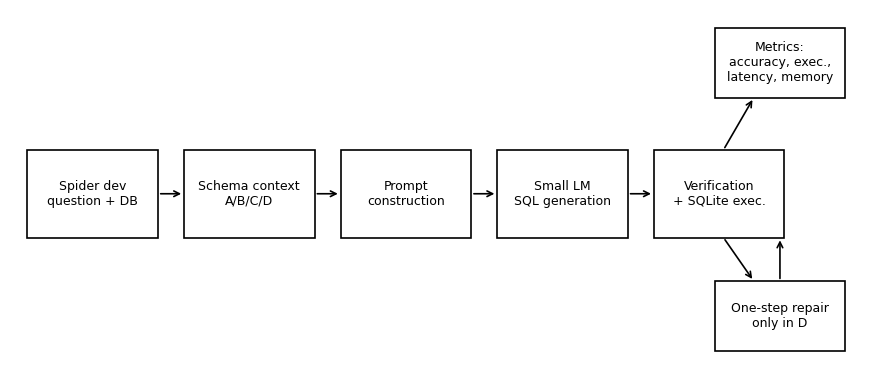

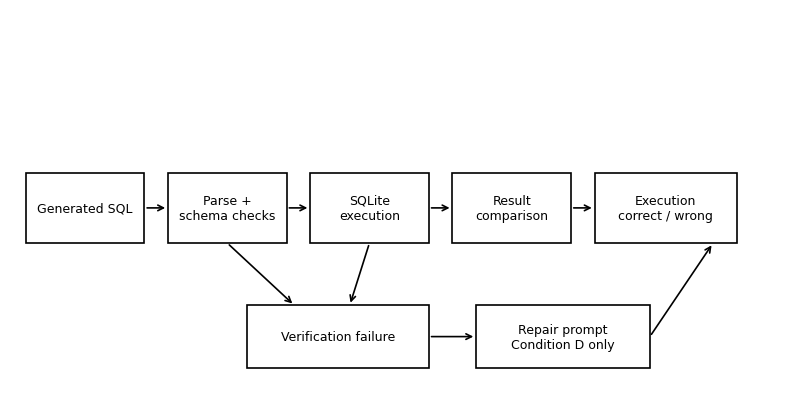

Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_benchmark_pipeline.png
Saved: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_verification_repair_flow.png


In [14]:
# Cell 14: Draw a benchmark pipeline figure and a verification/repair flow figure.

def add_box(ax, xy, w, h, text):
    rect = plt.Rectangle(xy, w, h, fill=False, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha="center", va="center", wrap=True, fontsize=9)

def add_arrow(ax, start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", linewidth=1.2))

# Main benchmark pipeline.
fig, ax = plt.subplots(figsize=(9.0, 3.8))
ax.set_axis_off()
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)

boxes = [
    ((0.2, 1.4), 1.5, 1.0, "Spider dev\nquestion + DB"),
    ((2.0, 1.4), 1.5, 1.0, "Schema context\nA/B/C/D"),
    ((3.8, 1.4), 1.5, 1.0, "Prompt\nconstruction"),
    ((5.6, 1.4), 1.5, 1.0, "Small LM\nSQL generation"),
    ((7.4, 1.4), 1.5, 1.0, "Verification\n+ SQLite exec."),
    ((8.1, 0.1), 1.5, 0.8, "One-step repair\nonly in D"),
    ((8.1, 3.0), 1.5, 0.8, "Metrics:\naccuracy, exec.,\nlatency, memory"),
]
for xy, w, h, text in boxes:
    add_box(ax, xy, w, h, text)

add_arrow(ax, (1.7, 1.9), (2.0, 1.9))
add_arrow(ax, (3.5, 1.9), (3.8, 1.9))
add_arrow(ax, (5.3, 1.9), (5.6, 1.9))
add_arrow(ax, (7.1, 1.9), (7.4, 1.9))
add_arrow(ax, (8.2, 1.4), (8.55, 0.9))
add_arrow(ax, (8.85, 0.9), (8.85, 1.4))
add_arrow(ax, (8.2, 2.4), (8.55, 3.0))

fig.tight_layout()
pipeline_path = MATERIALS_DIR / "fig_benchmark_pipeline.png"
fig.savefig(pipeline_path, dpi=300, bbox_inches="tight")
plt.show()

# Verification/repair flow.
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.set_axis_off()
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)

flow_boxes = [
    ((0.2, 2.0), 1.5, 0.9, "Generated SQL"),
    ((2.0, 2.0), 1.5, 0.9, "Parse +\nschema checks"),
    ((3.8, 2.0), 1.5, 0.9, "SQLite\nexecution"),
    ((5.6, 2.0), 1.5, 0.9, "Result\ncomparison"),
    ((7.4, 2.0), 1.8, 0.9, "Execution\ncorrect / wrong"),
    ((3.0, 0.4), 2.3, 0.8, "Verification failure"),
    ((5.9, 0.4), 2.2, 0.8, "Repair prompt\nCondition D only"),
]
for xy, w, h, text in flow_boxes:
    add_box(ax, xy, w, h, text)

add_arrow(ax, (1.7, 2.45), (2.0, 2.45))
add_arrow(ax, (3.5, 2.45), (3.8, 2.45))
add_arrow(ax, (5.3, 2.45), (5.6, 2.45))
add_arrow(ax, (7.1, 2.45), (7.4, 2.45))
add_arrow(ax, (2.75, 2.0), (3.6, 1.2))
add_arrow(ax, (4.55, 2.0), (4.3, 1.2))
add_arrow(ax, (5.3, 0.8), (5.9, 0.8))
add_arrow(ax, (8.1, 0.8), (8.9, 2.0))

fig.tight_layout()
flow_path = MATERIALS_DIR / "fig_verification_repair_flow.png"
fig.savefig(flow_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pipeline_path)
print("Saved:", flow_path)


In [15]:
# Cell 15: Optional model-output example table from saved benchmark results.
# This cell runs only if all_model_outputs.parquet exists.

outputs_path = RESULTS_DIR / "all_model_outputs.parquet"

if outputs_path.exists():
    all_outputs = pd.read_parquet(outputs_path)
    print("Loaded outputs:", all_outputs.shape)

    subset = all_outputs[
        (all_outputs["example_id"].astype(int) == example_id)
        & (all_outputs["condition"].astype(str) == "D")
    ].copy()

    if subset.empty:
        print("No saved model outputs found for representative example under Condition D.")
    else:
        cols = [
            "model_name",
            "verification_status",
            "execution_correct",
            "final_sql",
            "repair_attempted",
            "generation_latency_sec",
        ]
        available_cols = [c for c in cols if c in subset.columns]
        model_example = subset[available_cols].copy()

        if "final_sql" in model_example.columns:
            model_example["final_sql_short"] = model_example["final_sql"].apply(lambda x: shorten(x, 160))

        model_example.to_csv(MATERIALS_DIR / "condition_D_model_outputs_for_representative_example.csv", index=False)
        display(model_example)

        latex_lines = []
        latex_lines.append(r"\begin{table}[!tbp]")
        latex_lines.append(r"\centering")
        latex_lines.append(r"\caption{Example Condition-D outputs for one representative Spider question. This table is intended as an illustrative benchmark-design example, not as aggregate performance evidence.}")
        latex_lines.append(r"\label{tab:example_model_outputs}")
        latex_lines.append(r"\scriptsize")
        latex_lines.append(r"\begin{tabular}{p{3.0cm}p{2.4cm}cp{5.2cm}}")
        latex_lines.append(r"\toprule")
        latex_lines.append(r"\textbf{Model} & \textbf{Verification} & \textbf{Correct} & \textbf{Final SQL} \\")
        latex_lines.append(r"\midrule")

        for _, r in model_example.iterrows():
            latex_lines.append(
                f'{latex_escape(r.get("model_name", ""))} & '
                f'{latex_escape(r.get("verification_status", ""))} & '
                f'{latex_escape(r.get("execution_correct", ""))} & '
                f'{latex_escape(shorten(r.get("final_sql", ""), 150))} \\\\'
            )

        latex_lines.append(r"\bottomrule")
        latex_lines.append(r"\end{tabular}")
        latex_lines.append(r"\end{table}")

        model_latex = "\n".join(latex_lines)
        (MATERIALS_DIR / "tab_example_model_outputs.tex").write_text(model_latex, encoding="utf-8")
        print(model_latex)
        print("Saved:", MATERIALS_DIR / "tab_example_model_outputs.tex")
else:
    print("Skipped: all_model_outputs.parquet not found.")
    print("Run the original benchmark notebook first if you want this optional model-output example table.")


Loaded outputs: (41821, 48)


,model_name,verification_status,execution_correct,final_sql,repair_attempted,generation_latency_sec,final_sql_short
639,Qwen3-0.6B,success,0.0,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars_data),0.0,1.816143,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars_data)
4864,Qwen3-1.7B,success,0.0,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars_data),0.0,2.374687,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars_data)
9140,Qwen3-4B-Instruct-2507,success,0.0,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT Accelerate FROM cars_data ORDER BY CAST(Horsepower AS INTEGER) DESC LIMIT 1),0.0,4.949768,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT Accelerate FROM cars_data ORDER BY CAST(Horsepower AS INTEGER) DESC LIMIT 1)
13332,Gemma-4-E2B-it,success,0.0,SELECT count(*) FROM cars_data WHERE Accelerate > (SELECT MAX(T1.Horsepower) FROM cars_data AS T1),0.0,4.843621,SELECT count(*) FROM cars_data WHERE Accelerate > (SELECT MAX(T1.Horsepower) FROM cars_data AS T1)
17524,Gemma-4-E4B-it,success,0.0,SELECT count(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Accelerate) FROM cars_data WHERE Horsepower = (SELECT MAX(Horsepower) FROM cars_data)),0.0,8.269380,SELECT count(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Accelerate) FROM cars_data WHERE Horsepower = (SELECT MAX(Horsepower) FROM cars_data))
21692,Llama-3.2-1B-Instruct,schema_error,0.0,SELECT COUNT(*) FROM cars_data AS T1 INNER JOIN model_list AS T2 ON T1.Horsepower = T2.Horsepower INNER JOIN car_makers AS T3 ON T1.MakeId = T3.Id INNER JOI...,1.0,5.916023,SELECT COUNT(*) FROM cars_data AS T1 INNER JOIN model_list AS T2 ON T1.Horsepower = T2.Horsepower INNER JOIN car_makers AS T3 ON T1.MakeId = T3.Id INNER JOI...
25856,Llama-3.2-3B-Instruct,success,0.0,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars_data),0.0,2.759375,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars_data)
30024,Granite-3.3-2B-Instruct,success,1.0,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT Accelerate FROM cars_data WHERE Horsepower = (SELECT MAX(Horsepower) FROM cars_data)),0.0,5.142574,SELECT COUNT(*) FROM cars_data WHERE Accelerate > (SELECT Accelerate FROM cars_data WHERE Horsepower = (SELECT MAX(Horsepower) FROM cars_data))
34172,SmolLM3-3B,parse_error,0.0,"select the maximum horsepower. Then, compare each car's accelerate to that maximum. But wait, the user wants the count of cars where accelerate is larger th...",1.0,22.347411,"select the maximum horsepower. Then, compare each car's accelerate to that maximum. But wait, the user wants the count of cars where accelerate is larger th..."
38318,Phi-4-mini-instruct,success,0.0,SELECT COUNT(*) AS car_count FROM cars_data AS cd WHERE cd.Accelerate > ( SELECT MAX(cds2.Horsepower) FROM cars_data AS cds2 ),0.0,4.495138,SELECT COUNT(*) AS car_count FROM cars_data AS cd WHERE cd.Accelerate > ( SELECT MAX(cds2.Horsepower) FROM cars_data AS cds2 )


\begin{table}[!tbp]
\centering
\caption{Example Condition-D outputs for one representative Spider question. This table is intended as an illustrative benchmark-design example, not as aggregate performance evidence.}
\label{tab:example_model_outputs}
\scriptsize
\begin{tabular}{p{3.0cm}p{2.4cm}cp{5.2cm}}
\toprule
\textbf{Model} & \textbf{Verification} & \textbf{Correct} & \textbf{Final SQL} \\
\midrule
Qwen3-0.6B & success & 0.0 & SELECT COUNT(*) FROM cars\_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars\_data) \\
Qwen3-1.7B & success & 0.0 & SELECT COUNT(*) FROM cars\_data WHERE Accelerate > (SELECT MAX(Horsepower) FROM cars\_data) \\
Qwen3-4B-Instruct-2507 & success & 0.0 & SELECT COUNT(*) FROM cars\_data WHERE Accelerate > (SELECT Accelerate FROM cars\_data ORDER BY CAST(Horsepower AS INTEGER) DESC LIMIT 1) \\
Gemma-4-E2B-it & success & 0.0 & SELECT count(*) FROM cars\_data WHERE Accelerate > (SELECT MAX(T1.Horsepower) FROM cars\_data AS T1) \\
Gemma-4-E4B-it & success & 0.

In [16]:
# Cell 16: Write recommended Section 3 insertion snippets.

suggestions = r'''
# Recommended additions to Section 3: Benchmark Design

## Best additions to include in the main paper

1. Add a small representative-example table near the start of Section 3.1.
   - Use `tab_benchmark_examples.tex`.
   - Purpose: makes the benchmark concrete by showing actual natural-language questions, gold SQL, and schema-context sizes.

2. Add the prompt template after the paragraph that describes prompting.
   - Use `fig_generation_prompt_template.tex`.
   - Purpose: reviewers can see the exact task instruction instead of only reading a verbal summary.

3. Add a verification-flow table or diagram in the verification subsection.
   - Use either `tab_verification_flow.tex` or `fig_verification_repair_flow.png`.
   - Purpose: strengthens the paper against reviewer concerns about experimental design and reliability.

4. Add the schema/prompt-size statistics table if page space allows.
   - Use `tab_context_prompt_stats.tex`.
   - Purpose: explains what "full", "pruned", and "augmented" actually change quantitatively.

5. Keep the full Condition-D prompt example in appendix/supplement if the main paper is tight.
   - Use `representative_prompt_and_schema_example.md` and `condition_D_prompt_example.txt`.
   - Purpose: transparency without taking too much LNCS page space.

## Suggested paragraph for Section 3.1

To make the benchmark setting explicit, Table~\ref{tab:benchmark_examples}
shows representative Spider development examples used by the harness. The
examples cover simple lookup, aggregation, multi-table, nested, and
order/limit queries. For each example, the table also reports the schema
context length under the full, pruned, and pruned-augmented settings. This
makes clear that the experimental conditions change the prompt context rather
than the underlying database or gold SQL.

## Suggested paragraph for Section 3.3

Fig.~\ref{fig:generation_prompt} shows the fixed generation template used
across all models. The only prompt component that changes across Conditions
A--C is the schema block. Condition D uses the same pruned augmented schema
as Condition C, but adds a one-step repair prompt only when verification
fails. This design isolates the effects of schema context and repair while
keeping the model instruction and decoding setup fixed.

## Suggested paragraph for verification

Table~\ref{tab:verification_flow} summarizes the verification stages applied
before execution-accuracy comparison. The verifier checks that the model
output is a SQLite-compatible SELECT query, parses under the SQLite dialect,
references known schema tables, avoids unsafe comma-style Cartesian products,
and executes successfully against the original SQLite database. In Condition
D, failures at these stages trigger at most one repair attempt. Executable but
semantically incorrect SQL is not repaired by this verifier and is counted as
incorrect.
'''

(MATERIALS_DIR / "section3_insert_suggestions.md").write_text(suggestions, encoding="utf-8")
print(suggestions)
print("Saved:", MATERIALS_DIR / "section3_insert_suggestions.md")



# Recommended additions to Section 3: Benchmark Design

## Best additions to include in the main paper

1. Add a small representative-example table near the start of Section 3.1.
   - Use `tab_benchmark_examples.tex`.
   - Purpose: makes the benchmark concrete by showing actual natural-language questions, gold SQL, and schema-context sizes.

2. Add the prompt template after the paragraph that describes prompting.
   - Use `fig_generation_prompt_template.tex`.
   - Purpose: reviewers can see the exact task instruction instead of only reading a verbal summary.

3. Add a verification-flow table or diagram in the verification subsection.
   - Use either `tab_verification_flow.tex` or `fig_verification_repair_flow.png`.
   - Purpose: strengthens the paper against reviewer concerns about experimental design and reliability.

4. Add the schema/prompt-size statistics table if page space allows.
   - Use `tab_context_prompt_stats.tex`.
   - Purpose: explains what "full", "pruned", and "augment

In [17]:
# Cell 17: Create a manifest of generated files.

generated = []
for p in sorted(MATERIALS_DIR.glob("*")):
    if p.is_file():
        generated.append({
            "filename": p.name,
            "path": str(p),
            "size_bytes": p.stat().st_size,
        })

manifest = pd.DataFrame(generated)
manifest.to_csv(MATERIALS_DIR / "manifest.csv", index=False)
display(manifest)

print("All materials written to:", MATERIALS_DIR)


,filename,path,size_bytes
0,benchmark_design_example_entries.csv,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/benchmark_design_example_entries.csv,2003
1,condition_D_model_outputs_for_representative_example.csv,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/condition_D_model_outputs_for_representative_example.csv,3859
2,condition_D_prompt_example.txt,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/condition_D_prompt_example.txt,1373
3,condition_D_repair_prompt_example.txt,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/condition_D_repair_prompt_example.txt,1409
4,fig_benchmark_pipeline.png,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_benchmark_pipeline.png,95493
5,fig_generation_prompt_template.tex,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_generation_prompt_template.tex,792
6,fig_prompt_length_by_condition.png,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_prompt_length_by_condition.png,89958
7,fig_repair_prompt_template.tex,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_repair_prompt_template.tex,500
8,fig_schema_context_compression.png,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_schema_context_compression.png,79671
9,fig_verification_repair_flow.png,/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials/fig_verification_repair_flow.png,88728


All materials written to: /content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials


In [18]:
# Download all generated Benchmark Design materials as one ZIP file

from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from datetime import datetime
from google.colab import files

# Candidate output folders used by the benchmark-design material notebook
candidate_dirs = [
    Path("/content/drive/MyDrive/nl2sql_sqlite/benchmark_design_materials"),
    Path("/content/gdrive/MyDrive/nl2sql_sqlite/benchmark_design_materials"),
    Path("/content/drive_mount/MyDrive/nl2sql_sqlite/benchmark_design_materials"),
    Path("/content/nl2sql_sqlite/benchmark_design_materials"),
    Path("/content/benchmark_design_materials"),
]

# Candidate loose output files, in case your notebook wrote them into /content
candidate_files = [
    Path("/content/tab_benchmark_examples.tex"),
    Path("/content/fig_generation_prompt_template.tex"),
    Path("/content/fig_repair_prompt_template.tex"),
    Path("/content/tab_verification_flow.tex"),
    Path("/content/fig_benchmark_pipeline.png"),
    Path("/content/fig_verification_repair_flow.png"),
    Path("/content/fig_prompt_length_by_condition.png"),
    Path("/content/tab_context_prompt_stats.tex"),
    Path("/content/section3_insert_suggestions.md"),
]

existing_dirs = [p for p in candidate_dirs if p.exists() and p.is_dir()]
existing_files = [p for p in candidate_files if p.exists() and p.is_file()]

if not existing_dirs and not existing_files:
    raise FileNotFoundError(
        "No generated materials found. Run the material-generation cells first, then run this cell.\n"
        "Checked folders:\n"
        + "\n".join(str(p) for p in candidate_dirs)
        + "\n\nChecked files:\n"
        + "\n".join(str(p) for p in candidate_files)
    )

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = Path(f"/content/apweb_waim_2026_benchmark_design_materials_{timestamp}.zip")

with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as zf:
    # Add whole generated-material folders
    for folder in existing_dirs:
        for item in folder.rglob("*"):
            if item.is_file():
                arcname = Path(folder.name) / item.relative_to(folder)
                zf.write(item, arcname)

    # Add loose files if they exist
    for item in existing_files:
        zf.write(item, Path("loose_generated_materials") / item.name)

print("Created ZIP:", zip_path)
print("Size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

files.download(str(zip_path))

Created ZIP: /content/apweb_waim_2026_benchmark_design_materials_20260701_085225.zip
Size MB: 0.3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>